In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
df = pd.read_csv('wine_data.csv',usecols=['class_label','alcohol','malic_acid'])
df.head()

,class_label,alcohol,malic_acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59


/var/folders/1f/6m1mrc854l70_ftx18ysbs_r0000gn/T/ipykernel_1494/2997577482.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['alcohol'],shade=True)


<Axes: xlabel='alcohol', ylabel='Density'>

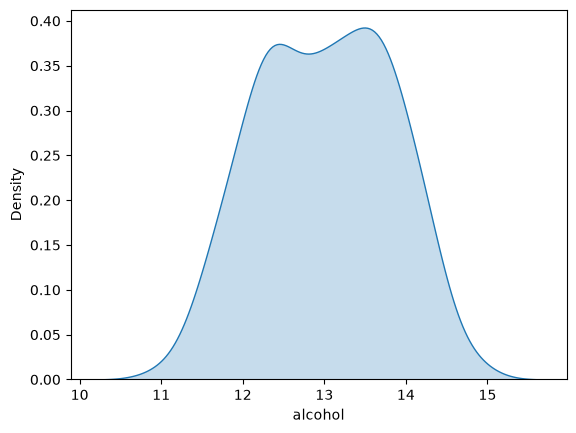

In [45]:
sns.kdeplot(df['alcohol'],shade=True)

/var/folders/1f/6m1mrc854l70_ftx18ysbs_r0000gn/T/ipykernel_1494/4006221840.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['malic_acid'],shade=True)


<Axes: xlabel='malic_acid', ylabel='Density'>

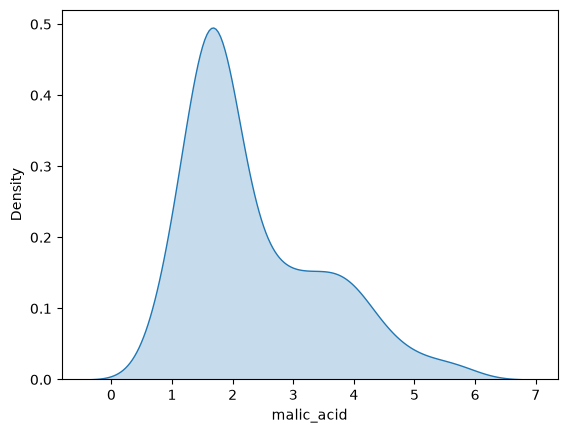

In [46]:
sns.kdeplot(df['malic_acid'],shade=True)

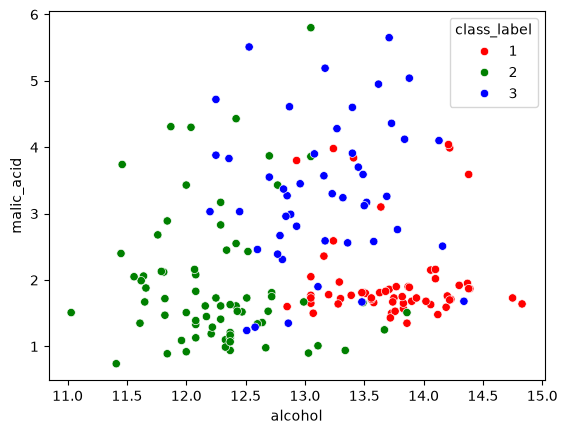

In [47]:
color_dict = {1:'red', 2:'green', 3:'blue'}
sns.scatterplot(data=df,x='alcohol',y='malic_acid',hue='class_label',palette=color_dict)
plt.show()

In [48]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.drop('class_label', axis=1),
                                                 df['class_label'],
                                                 test_size=0.3,
                                                 random_state=0)

In [49]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
# Fit the scaler on the train set, it will learn the parameters (mean and standard deviation) from the training data only.
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [50]:
# Convert the scaled arrays back to DataFrames
X_train_scaled = pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled,columns=X_test.columns)

In [51]:
np.round(X_train.describe(),1)

,alcohol,malic_acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [52]:
np.round(X_train_scaled.describe(),1)

,alcohol,malic_acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


# Visual Effect of Scaling

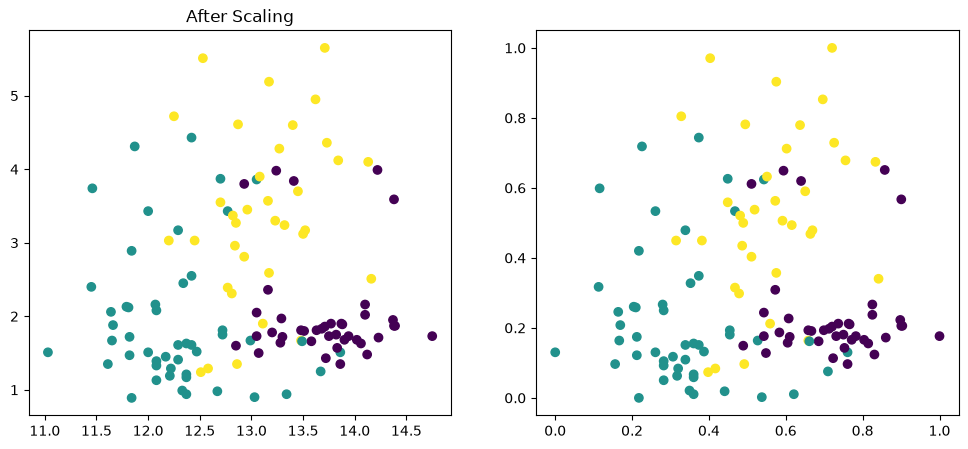

In [ ]:
fig,(ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))
ax1.scatter(data=X_train,x='alcohol',y='malic_acid',c=y_train)
ax1.set_title('Before Scaling')
ax2.scatter(data=X_train_scaled,x='alcohol',y='malic_acid',c=y_train)
ax1.set_title('After Scaling')
plt.show()

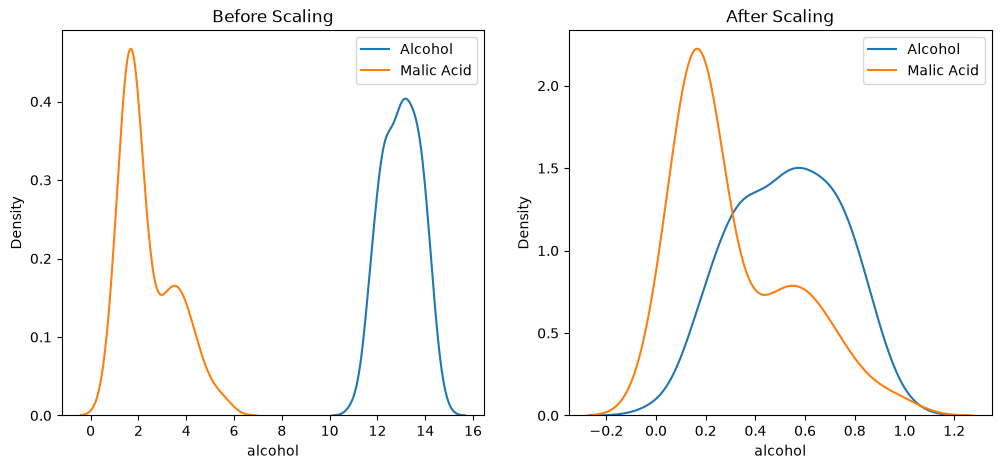

In [60]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

sns.kdeplot(X_train['alcohol'], ax=ax1, label='Alcohol')
sns.kdeplot(X_train['malic_acid'], ax=ax1, label='Malic Acid')
ax1.set_title('Before Scaling')
ax1.legend()

sns.kdeplot(X_train_scaled['alcohol'], ax=ax2, label='Alcohol')
sns.kdeplot(X_train_scaled['malic_acid'], ax=ax2, label='Malic Acid')
ax2.set_title('After Scaling')
ax2.legend()

plt.show()

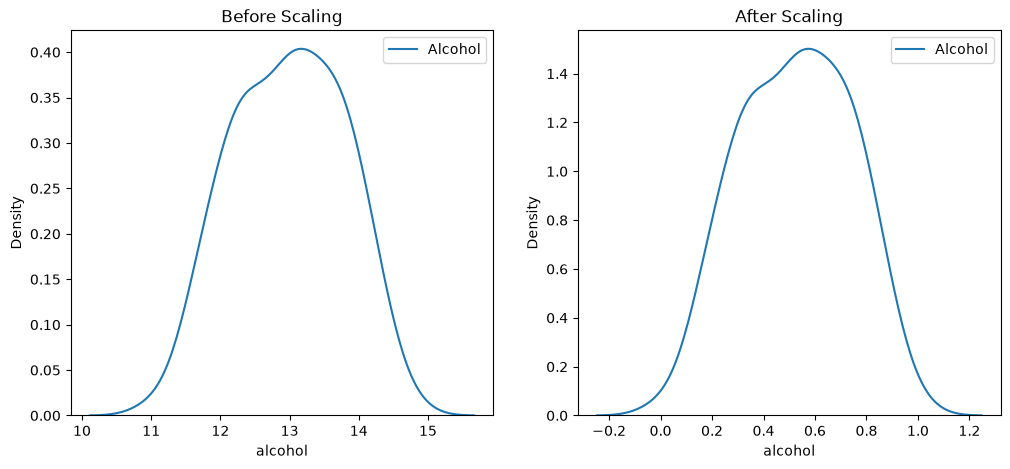

In [63]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

sns.kdeplot(X_train['alcohol'], ax=ax1, label='Alcohol')
ax1.set_title('Before Scaling')
ax1.legend()

sns.kdeplot(X_train_scaled['alcohol'], ax=ax2, label='Alcohol')
ax2.set_title('After Scaling')
ax2.legend()

plt.show()

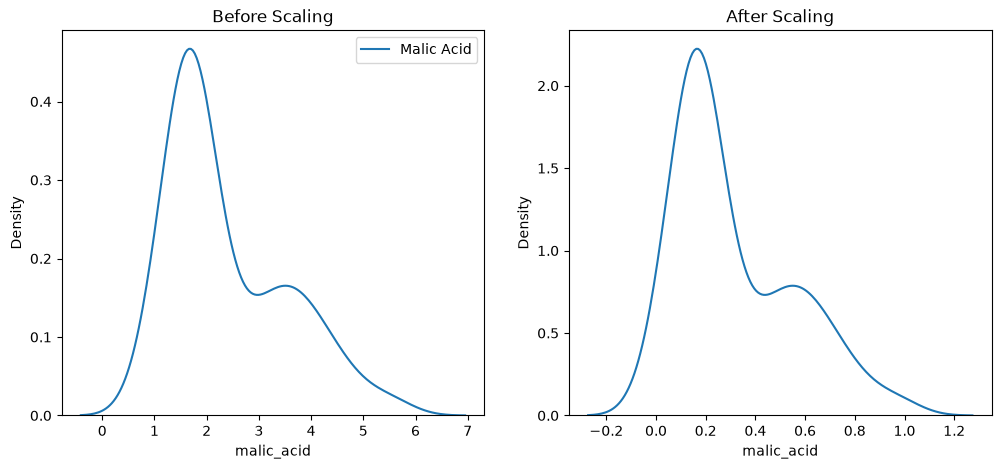

In [61]:

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

sns.kdeplot(X_train['malic_acid'], ax=ax1, label='Malic Acid')
ax1.set_title('Before Scaling')
ax1.legend()

sns.kdeplot(X_train_scaled['malic_acid'], ax=ax2, label='Malic Acid')
ax2.set_title('After Scaling')
ax1.legend()

plt.show()